<a href="https://colab.research.google.com/github/cgm2179/Branch_2_Diffusion_Transformer_efficiency_for_small_model/blob/main/Section%208%20-%20Cameron's%20Version/regime%201%20-%20CelebA/CelebA%20-%2006_compare_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 8 — regime 1 (CelebA) · Compare Results
Loads the 5 methods' `results/*.json` from Drive (missing ones skipped). BCE + mean-attribute accuracy, cost/memory, three-factor cos-sweep head-to-head, a per-attribute accuracy bar, and a figures+CSV export.

## 1. Setup + Load Results

In [1]:
import os, json, math, torch
import torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
device='cuda' if torch.cuda.is_available() else 'cpu'
USE_DRIVE, DRIVE_SUBDIR = True, 'Section8_r1_celeba'
if USE_DRIVE:
    try:
        from google.colab import drive; drive.mount('/content/drive'); STORE=os.path.join('/content/drive/MyDrive',DRIVE_SUBDIR)
    except Exception as e:
        print('Drive mount failed:',e); STORE=os.path.join('/content',DRIVE_SUBDIR)
else:
    STORE=os.path.join('.',DRIVE_SUBDIR)
RESULTS_DIR=os.path.join(STORE,'results'); CKPT_DIR=os.path.join(STORE,'checkpoints')
EXTRA_RESULTS_DIRS = []   # merge results JSONs exported from other Google accounts
EXTRA_CKPT_DIRS    = []
METHODS=['backprop','two_factor','three_factor_clean','three_factor_normal','three_factor_noisy','backprop_100M']
LABELS={'backprop':'Backprop','two_factor':'Two-factor Hebbian','three_factor_clean':'Three-factor clean (cos~0.5)','three_factor_normal':'Three-factor normal (cos~0.09)','three_factor_noisy':'Three-factor noisy (cos~0.01)','backprop_100M':'Backprop 100M (ceiling)'}
COLORS={'backprop':'#1F3864','two_factor':'#B8860B','three_factor_clean':'#C62828','three_factor_normal':'#E67E22','three_factor_noisy':'#7B1FA2','backprop_100M':'#2E7D32'}
def _find(m):
    for d in [RESULTS_DIR]+EXTRA_RESULTS_DIRS:
        p=os.path.join(d,f'{m}.json')
        if os.path.exists(p): return p
    return None
R={}
for m in METHODS:
    p=_find(m)
    if p:
        R[m]=json.load(open(p)); s=R[m]['summary']; md=R[m]['meta']
        print(f'loaded {m:24} {md["total_steps"]:>9,} steps  {md["wall_clock_sec"]/3600:5.2f}h  best BCE {s["best_loss"]:.4f}  best mean-attr-acc {s["best_acc"]:.4f}')
    else:
        print(f'MISSING {m}.json (run the {m} notebook first)')

Mounted at /content/drive
loaded backprop                   685,375 steps   2.00h  best BCE 0.2603  best mean-attr-acc 0.8878
loaded two_factor                 847,168 steps   2.00h  best BCE 0.7061  best mean-attr-acc 0.7747
loaded three_factor_clean               7 steps   2.16h  best BCE 0.4515  best mean-attr-acc 0.8015
loaded three_factor_normal            265 steps   2.01h  best BCE 0.4219  best mean-attr-acc 0.8092
loaded three_factor_noisy          20,732 steps   2.00h  best BCE 0.3463  best mean-attr-acc 0.8520
loaded backprop_100M               36,599 steps   2.00h  best BCE 0.2728  best mean-attr-acc 0.8804


## (optional) merge results from another account

In [2]:
# --- OPTIONAL: merge results exported from ANOTHER Google account (upload <method>.json / .pt) ---
import os
try:
    from google.colab import files
    up = files.upload(); import shutil
    for fn in up:
        dst = '/content/extra_results' if fn.endswith('.json') else '/content/extra_ckpts'
        os.makedirs(dst, exist_ok=True); shutil.move(fn, os.path.join(dst, fn))
    if os.path.isdir('/content/extra_results') and '/content/extra_results' not in EXTRA_RESULTS_DIRS:
        EXTRA_RESULTS_DIRS.append('/content/extra_results')
    if os.path.isdir('/content/extra_ckpts') and '/content/extra_ckpts' not in EXTRA_CKPT_DIRS:
        EXTRA_CKPT_DIRS.append('/content/extra_ckpts')
    print('re-run the load cell above; EXTRA_RESULTS_DIRS =', EXTRA_RESULTS_DIRS)
except Exception as e:
    print('nothing uploaded (fine if all results are on this Drive):', e)

re-run the load cell above; EXTRA_RESULTS_DIRS = []


## 2. Compare curves (BCE + mean-attr accuracy)

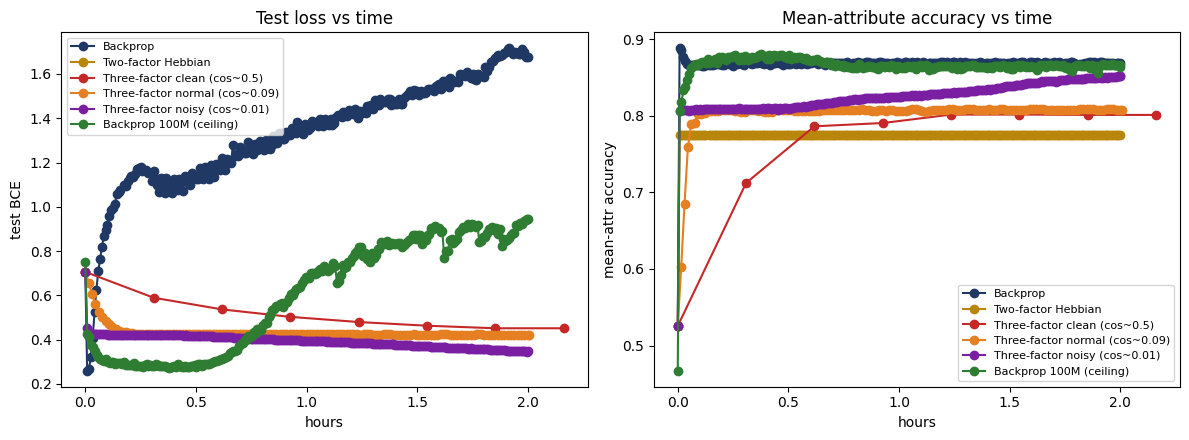

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for m in R:
    c = R[m]['curve']; hrs = [t/3600 for t in c['t_sec']]
    ax[0].plot(hrs, c['test_loss'], 'o-', color=COLORS[m], label=LABELS[m])
    ax[1].plot(hrs, c['test_acc'],  'o-', color=COLORS[m], label=LABELS[m])
ax[0].set_xlabel('hours'); ax[0].set_ylabel('test BCE'); ax[0].set_title('Test loss vs time'); ax[0].legend(fontsize=8)
ax[1].set_xlabel('hours'); ax[1].set_ylabel('mean-attr accuracy'); ax[1].set_title('Mean-attribute accuracy vs time'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3. Cost & Memory

In [4]:
def fwd_equiv(m):
    st = R[m]['meta']['total_steps']
    if m.startswith('three_factor'): return st * 2 * R[m]['meta']['config'].get('M', 0)
    if m.startswith('backprop'): return st * 3
    return st * 2
print(f'{"method":30}{"steps":>10}{"fwd-equiv":>14}{"wall h":>8}{"peak MB":>9}')
print('-'*71)
for m in R:
    md = R[m]['meta']
    print(f'{LABELS[m]:30}{md["total_steps"]:>10,}{fwd_equiv(m):>14,}{md["wall_clock_sec"]/3600:>8.2f}{md.get("peak_mem_mb", float("nan")):>9.1f}')

method                             steps     fwd-equiv  wall h  peak MB
-----------------------------------------------------------------------
Backprop                         685,375     2,056,125    2.00   3296.9
Two-factor Hebbian               847,168     1,694,336    2.00   6393.6
Three-factor clean (cos~0.5)           7     4,909,296    2.16   5350.0
Three-factor normal (cos~0.09)       265     4,553,230    2.01   4525.1
Three-factor noisy (cos~0.01)     20,732     4,353,720    2.00   4520.3
Backprop 100M (ceiling)           36,599       109,797    2.00   6025.0


## 4. Head-to-head — three-factor cos sweep

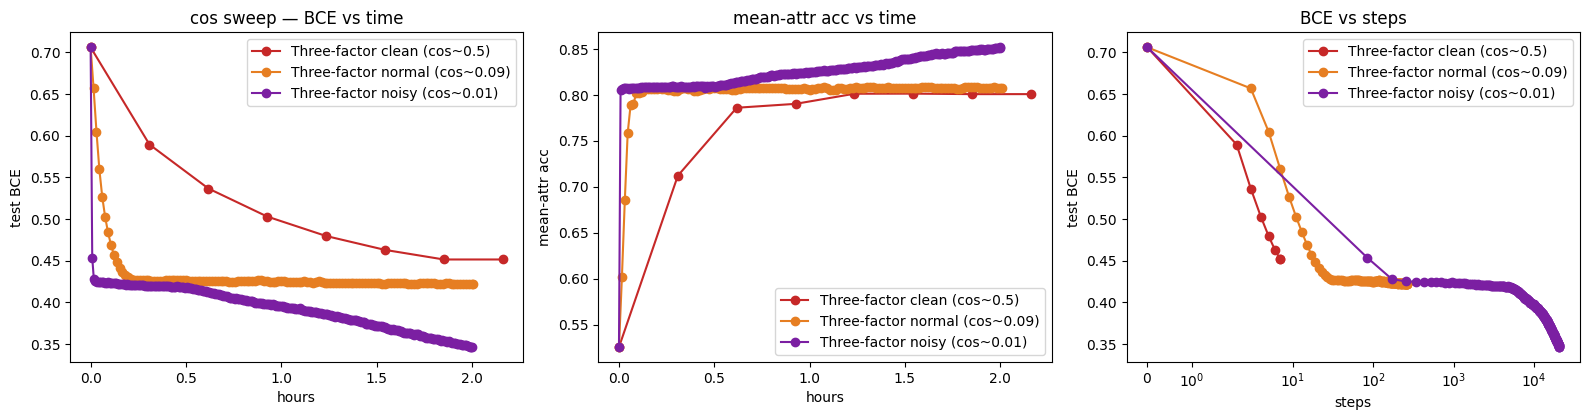

variant                                M    cos~     steps   best_bce  best_acc
-------------------------------------------------------------------------------
Three-factor clean (cos~0.5)     350,664   0.500         7     0.4515    0.8015
Three-factor normal (cos~0.09)     8,591   0.090       265     0.4219    0.8092
Three-factor noisy (cos~0.01)        105   0.010    20,732     0.3463    0.8520

Highest mean-attr accuracy in the budget: Three-factor noisy (cos~0.01).


In [5]:
tf = [m for m in ['three_factor_clean','three_factor_normal','three_factor_noisy'] if m in R]
if len(tf) >= 2:
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
    for m in tf:
        c = R[m]['curve']; hrs=[t/3600 for t in c['t_sec']]
        ax[0].plot(hrs, c['test_loss'], 'o-', color=COLORS[m], label=LABELS[m])
        ax[1].plot(hrs, c['test_acc'],  'o-', color=COLORS[m], label=LABELS[m])
        ax[2].plot(c['step'], c['test_loss'], 'o-', color=COLORS[m], label=LABELS[m])
    ax[0].set_xlabel('hours'); ax[0].set_ylabel('test BCE'); ax[0].set_title('cos sweep — BCE vs time'); ax[0].legend()
    ax[1].set_xlabel('hours'); ax[1].set_ylabel('mean-attr acc'); ax[1].set_title('mean-attr acc vs time'); ax[1].legend()
    ax[2].set_xscale('symlog'); ax[2].set_xlabel('steps'); ax[2].set_ylabel('test BCE'); ax[2].set_title('BCE vs steps'); ax[2].legend()
    plt.tight_layout(); plt.show()
    print(f'{"variant":30}{"M":>10}{"cos~":>8}{"steps":>10}{"best_bce":>11}{"best_acc":>10}')
    print('-'*79)
    for m in tf:
        md, s = R[m]['meta'], R[m]['summary']; M = md['config'].get('M') or 0; P = md['P']
        cos = (M/(M+P+1))**0.5 if M else float('nan')
        print(f'{LABELS[m]:30}{M:>10,}{cos:>8.3f}{md["total_steps"]:>10,}{s["best_loss"]:>11.4f}{s["best_acc"]:>10.4f}')
    best = max(tf, key=lambda m: R[m]['summary']['best_acc'])
    print(f'\nHighest mean-attr accuracy in the budget: {LABELS[best]}.')
else:
    print('Head-to-head needs >=2 three-factor variants (03/04/05).')

## Step 2.5 — CelebA data setup (Colab)

In [6]:
# --- Step 2.5 · CelebA data setup (run on Colab BEFORE Step 3) -------------------------------------
# Downloads the aligned CelebA JPGs + list_attr_celeba.csv to a LOCAL Colab path (fast; NOT Drive) and
# sets CELEBA_ROOT so Step 3 finds both the images and the 40-attribute labels. No-op if already present.
import os, glob, shutil
CELEBA_ROOT = globals().get('CELEBA_ROOT', '/content/celeba')   # local Colab disk (Step 3 caches a .pt here)
def _celeba_ready(root):
    return (bool(glob.glob(os.path.join(root, '**', '*.jpg'), recursive=True)) and
            bool(glob.glob(os.path.join(root, '**', 'list_attr_celeba.csv'), recursive=True)))
if not _celeba_ready(CELEBA_ROOT):
    # Option A -- Kaggle API (fast): upload kaggle.json (left panel > Files), then this pulls images + attrs:
    try:
        os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
        if os.path.exists('kaggle.json'):
            shutil.copy('kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
            os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
        os.system('pip -q install kaggle')
        os.system('kaggle datasets download -d jessicali9530/celeba-dataset -p "%s" --unzip -q' % CELEBA_ROOT)
    except Exception as e:
        print('Kaggle download failed:', e)
    # Option B -- from Google Drive (put celeba.zip on your Drive); uncomment to use instead of A:
    # from google.colab import drive; drive.mount('/content/drive')
    # os.makedirs(CELEBA_ROOT, exist_ok=True); os.system('unzip -q "/content/drive/MyDrive/celeba.zip" -d "%s"' % CELEBA_ROOT)
_n = len(glob.glob(os.path.join(CELEBA_ROOT, '**', '*.jpg'), recursive=True))
_has_csv = bool(glob.glob(os.path.join(CELEBA_ROOT, '**', 'list_attr_celeba.csv'), recursive=True))
assert _n and _has_csv, ('need CelebA jpgs AND list_attr_celeba.csv under %r -- upload kaggle.json (Option A) '
                         'or a Drive zip (Option B), or set CELEBA_ROOT to an existing folder.' % CELEBA_ROOT)
print('CELEBA_ROOT =', CELEBA_ROOT, '|', format(_n, ','), 'jpgs | attr csv present:', _has_csv)

CELEBA_ROOT = /content/celeba | 202,599 jpgs | attr csv present: True


## 5. Per-attribute accuracy (best model)

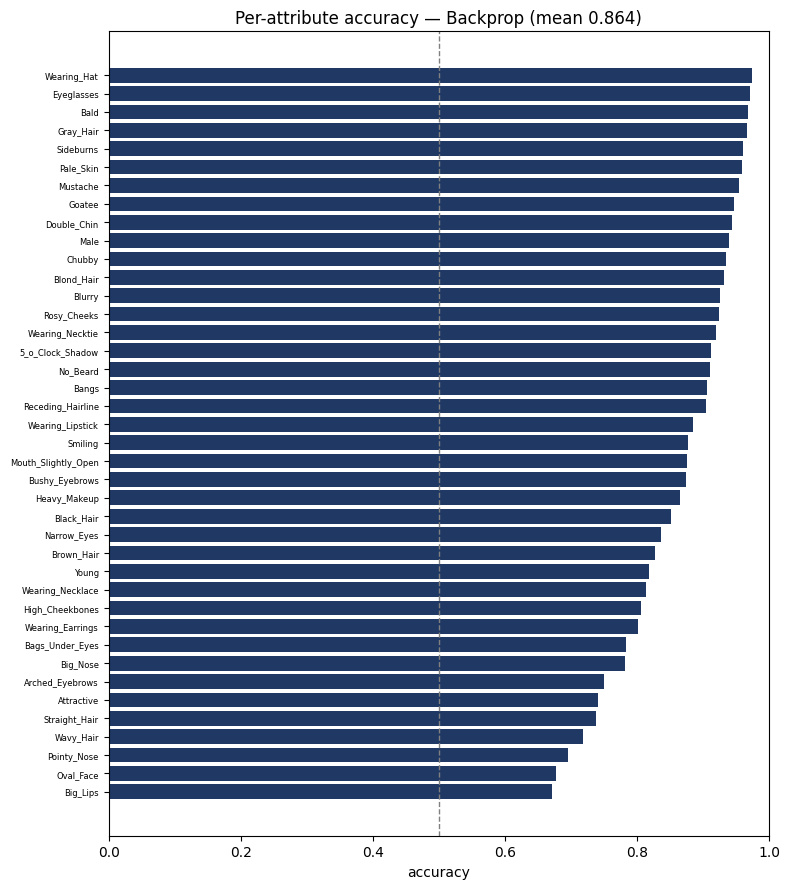

In [7]:
import math, torch
import torch.nn as nn
import torch.nn.functional as F

class MHSA(nn.Module):
    def __init__(self, dim, heads):
        super().__init__()
        assert dim % heads == 0, "EMBED_DIM must be divisible by HEADS"
        self.h, self.dh = heads, dim // heads
        self.scale = self.dh ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.h, self.dh).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        att = (q @ k.transpose(-2, -1)) * self.scale
        att = att.softmax(dim=-1)
        o = (att @ v).transpose(1, 2).reshape(B, N, D)
        return self.proj(o)

class Block(nn.Module):
    def __init__(self, dim, heads, mlp_ratio):
        super().__init__()
        self.n1 = nn.LayerNorm(dim); self.attn = MHSA(dim, heads)
        self.n2 = nn.LayerNorm(dim)
        h = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(dim, h), nn.GELU(), nn.Linear(h, dim))
    def forward(self, x):
        x = x + self.attn(self.n1(x))
        x = x + self.mlp(self.n2(x))
        return x

class ViT(nn.Module):
    def __init__(self, img=28, patch=7, in_ch=1, dim=176, depth=4, heads=8,
                 mlp_ratio=2, num_classes=10):
        super().__init__()
        assert img % patch == 0
        self.n = (img // patch) ** 2
        self.patch = nn.Conv2d(in_ch, dim, kernel_size=patch, stride=patch)
        self.cls = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos = nn.Parameter(torch.zeros(1, self.n + 1, dim))
        nn.init.trunc_normal_(self.pos, std=0.02)
        nn.init.trunc_normal_(self.cls, std=0.02)
        self.blocks = nn.ModuleList([Block(dim, heads, mlp_ratio) for _ in range(depth)])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, num_classes)
    def forward(self, x):
        B = x.shape[0]
        x = self.patch(x).flatten(2).transpose(1, 2)      # (B, n, dim)
        cls = self.cls.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)[:, 0]
        return self.head(x)

# per-attribute accuracy of the best model (highest mean-attr acc) on held-out CelebA faces
import os, glob, csv as _csv, numpy as np
from PIL import Image
def _ckpt(m):
    for d in [CKPT_DIR] + EXTRA_CKPT_DIRS:
        p = os.path.join(d, f'{m}.pt')
        if os.path.exists(p): return p
    return None
_avail = [m for m in R if _ckpt(m)]
if _avail:
    best = max(_avail, key=lambda m: R[m]['summary']['best_acc'])
    cfg = R[best]['meta']['config']
    net = ViT(cfg['IMG'], cfg['PATCH'], cfg['IN_CH'], cfg['EMBED_DIM'], cfg['DEPTH'], cfg['HEADS'], cfg['MLP_RATIO'], cfg['NUM_CLASSES']).to(device)
    ck = torch.load(_ckpt(best), map_location=device)['method']
    net.load_state_dict(ck['net'] if 'net' in ck else ck['params']); net.eval()
    CR = globals().get('CELEBA_ROOT', './celeba'); RES = cfg['IMG']
    _ac = next(iter(glob.glob(os.path.join(CR, '**', 'list_attr_celeba.csv'), recursive=True)), None)
    _rows = list(_csv.reader(open(_ac))); ATTR = _rows[0][1:]
    _lab = {r[0]: [(1 if v.strip()=='1' else 0) for v in r[1:]] for r in _rows[1:]}
    _fs = sorted(glob.glob(os.path.join(CR, '**', '*.jpg'), recursive=True))[-2000:]
    def _dec(p):
        im = Image.open(p).convert('RGB'); w, h = im.size; s = min(w, h)
        im = im.crop(((w-s)//2, (h-s)//2, (w+s)//2, (h+s)//2)).resize((RES, RES), Image.BILINEAR)
        return torch.from_numpy(np.asarray(im, dtype=np.float32)/255.0).permute(2, 0, 1)
    Xv = torch.stack([_dec(p) for p in _fs]).to(device)
    Yv = torch.tensor([_lab[os.path.basename(p)] for p in _fs], dtype=torch.float32, device=device)
    with torch.no_grad(): pred = (net(Xv) > 0).float()
    per = (pred == Yv).float().mean(0).cpu().numpy()          # (40,)
    order = np.argsort(per)
    fig, ax = plt.subplots(figsize=(8, 9))
    ax.barh(range(40), per[order], color='#1F3864')
    ax.set_yticks(range(40)); ax.set_yticklabels([ATTR[i] for i in order], fontsize=6)
    ax.axvline(0.5, color='gray', ls='--', lw=1); ax.set_xlim(0, 1); ax.set_xlabel('accuracy')
    ax.set_title(f'Per-attribute accuracy — {LABELS[best]} (mean {per.mean():.3f})')
    plt.tight_layout(); plt.show()
else:
    print('no checkpoints available (run the method notebooks first)')

## 6. Summary table

In [8]:
print(f'{"Experiment":30}{"Steps":>10}{"Init BCE":>10}{"Best BCE":>10}{"Final acc":>11}{"Best acc":>10}')
print('-'*81)
for m in R:
    md, s = R[m]['meta'], R[m]['summary']
    print(f'{LABELS[m]:30}{md["total_steps"]:>10,}{s["initial_loss"]:>10.4f}{s["best_loss"]:>10.4f}{s["final_acc"]:>11.4f}{s["best_acc"]:>10.4f}')

Experiment                         Steps  Init BCE  Best BCE  Final acc  Best acc
---------------------------------------------------------------------------------
Backprop                         685,375    0.7061    0.2603     0.8685    0.8878
Two-factor Hebbian               847,168    0.7061    0.7061     0.7747    0.7747
Three-factor clean (cos~0.5)           7    0.7061    0.4515     0.8010    0.8015
Three-factor normal (cos~0.09)       265    0.7061    0.4219     0.8072    0.8092
Three-factor noisy (cos~0.01)     20,732    0.7061    0.3463     0.8520    0.8520
Backprop 100M (ceiling)           36,599    0.7514    0.2728     0.8658    0.8804


## 7. Export figures + CSV → Drive

In [9]:
# Export figures (PNG) + data (CSV) -> a Drive folder, then download a zip.
import os, csv, glob, shutil
EXPORT_DIR = os.path.join(STORE, 'exports'); os.makedirs(EXPORT_DIR, exist_ok=True)
if R:
    ckeys = []
    for m in R:
        for k in R[m]['curve']:
            if k not in ckeys: ckeys.append(k)
    with open(os.path.join(EXPORT_DIR, 'curves.csv'), 'w', newline='') as f:
        w = csv.writer(f); w.writerow(['method'] + ckeys)
        for m in R:
            c = R[m]['curve']; n = len(c.get('t_sec', []))
            for i in range(n): w.writerow([m] + [c[k][i] if (k in c and i < len(c[k])) else '' for k in ckeys])
    skeys = []
    for m in R:
        for k in R[m]['summary']:
            if k not in skeys: skeys.append(k)
    with open(os.path.join(EXPORT_DIR, 'summary.csv'), 'w', newline='') as f:
        w = csv.writer(f); w.writerow(['method','P','total_steps','wall_clock_h','M','cos'] + skeys)
        for m in R:
            md, s = R[m]['meta'], R[m]['summary']; M = md['config'].get('M') or 0
            cos = round((M/(M+md['P']+1))**0.5, 4) if M else ''
            w.writerow([m, md['P'], md['total_steps'], round(md['wall_clock_sec']/3600,3), M, cos] + [s.get(k,'') for k in skeys])
    print('wrote curves.csv, summary.csv')
def _save(fig, name): fig.savefig(os.path.join(EXPORT_DIR, name), dpi=130, bbox_inches='tight'); plt.close(fig)
if R:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
    for m in R:
        c = R[m]['curve']; hrs=[t/3600 for t in c['t_sec']]
        ax[0].plot(hrs, c['test_loss'],'o-',color=COLORS[m],label=LABELS[m])
        ax[1].plot(hrs, c['test_acc'],'o-',color=COLORS[m],label=LABELS[m])
    ax[0].set_ylabel('test BCE'); ax[1].set_ylabel('mean-attr acc')
    for a in ax: a.set_xlabel('hours'); a.legend(fontsize=8)
    _save(fig, 'curves_bce_acc.png'); print('wrote comparison figure')
for d in {RESULTS_DIR, CKPT_DIR, STORE}:
    for png in glob.glob(os.path.join(d, '*.png')):
        try: shutil.copy(png, EXPORT_DIR)
        except Exception: pass
print('\nexport folder:', EXPORT_DIR); print(' ', sorted(os.listdir(EXPORT_DIR)))
_zt = '/content' if os.path.isdir('/content') else os.path.dirname(EXPORT_DIR)
zip_path = shutil.make_archive(os.path.join(_zt, DRIVE_SUBDIR + '_exports'), 'zip', EXPORT_DIR)
try:
    if os.path.abspath(os.path.dirname(zip_path)) != os.path.abspath(STORE): shutil.copy(zip_path, STORE)
except Exception as e: print('(could not copy zip to Drive):', e)
print('zip:', zip_path)
try:
    from google.colab import files; files.download(zip_path)
except Exception as e:
    print('(download only runs in Colab):', e)

wrote curves.csv, summary.csv
wrote comparison figure

export folder: /content/drive/MyDrive/Section8_r1_celeba/exports
  ['curves.csv', 'curves_bce_acc.png', 'summary.csv']
zip: /content/Section8_r1_celeba_exports.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>